# Tema : Modelos SARIMA
![](src/img/logo_utb.png){width=40%} 
![](src/img/logo_etd.png){width=40%}
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

## Ejemplo 1. Empleo mensual en el sector de ocio y hostelería en EE. UU

Describiremos la modelización ARIMA estacional utilizando datos mensuales de empleo en Estados Unidos para los trabajos de ocio y hospitalidad desde enero de 2001 hasta septiembre de 2019.

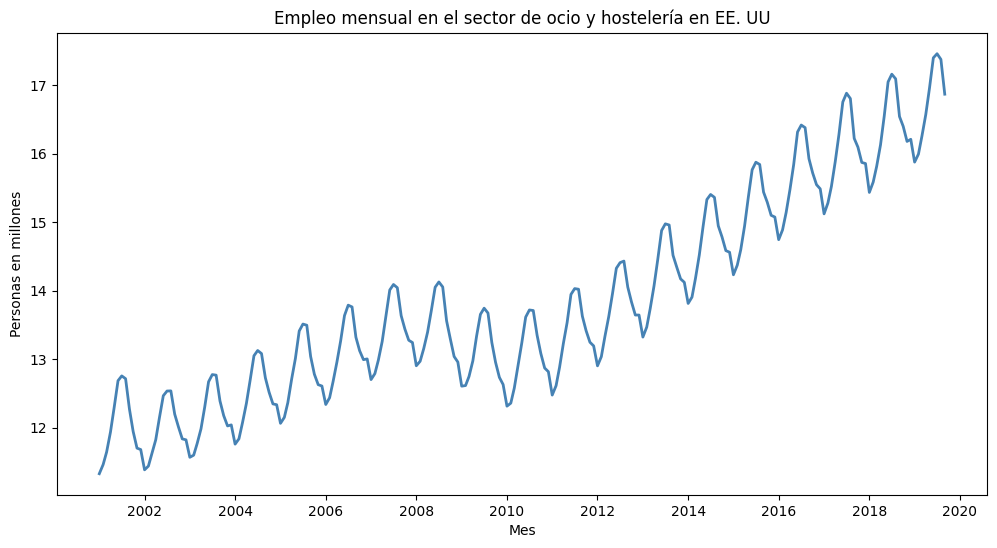

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.stattools import jarque_bera, durbin_watson
import warnings
warnings.filterwarnings('ignore')

# leer y ajustar datos
datos = pd.read_csv("../data/us_employment.csv", parse_dates=["ds"])
datos = datos.loc[(datos["ds"] >= "2001-01-01") & (datos["unique_id"] == "Leisure and Hospitality")].reset_index(drop=True)
datos["y"] = datos["y"] / 1e3
datos = datos.set_index('ds')
datos.index = pd.DatetimeIndex(datos.index).to_period('M').to_timestamp()
serie_us_employment = datos.y

# grafico serie
plt.figure(figsize=(12, 6))
plt.plot(serie_us_employment.index, serie_us_employment, color='steelblue', linewidth=2)
plt.xlabel('Mes')
plt.ylabel('Personas en millones')
plt.title('Empleo mensual en el sector de ocio y hostelería en EE. UU')
plt.show()

Los datos son claramente no estacionarios, con una fuerte estacionalidad y una tendencia no lineal, por lo que primero tomaremos una diferencia estacional. Los datos con diferencia estacional se muestran en la figura siguiente.


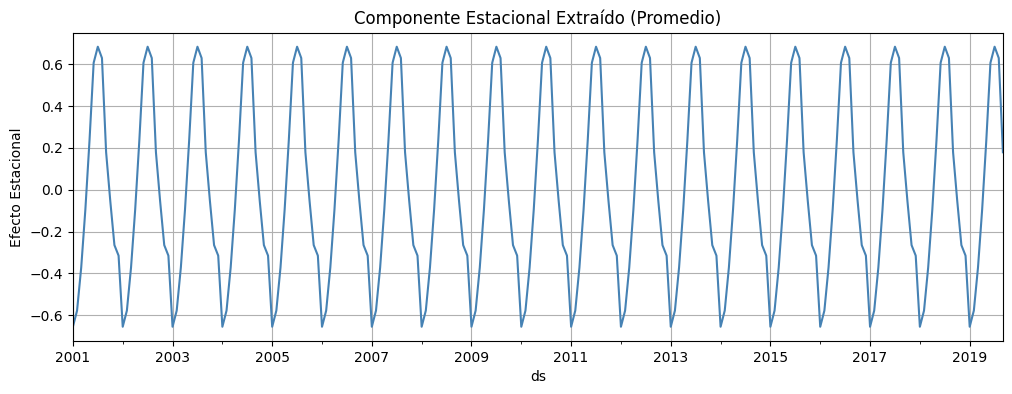

In [2]:

# Descomposición aditiva
descomposicion = seasonal_decompose(serie_us_employment, model='additive')

# Graficar solo el componente estacional
plt.figure(figsize=(12, 4))
descomposicion.seasonal.plot(color='steelblue')
plt.title('Componente Estacional Extraído (Promedio)')
plt.ylabel('Efecto Estacional')
plt.grid(True)
plt.show()

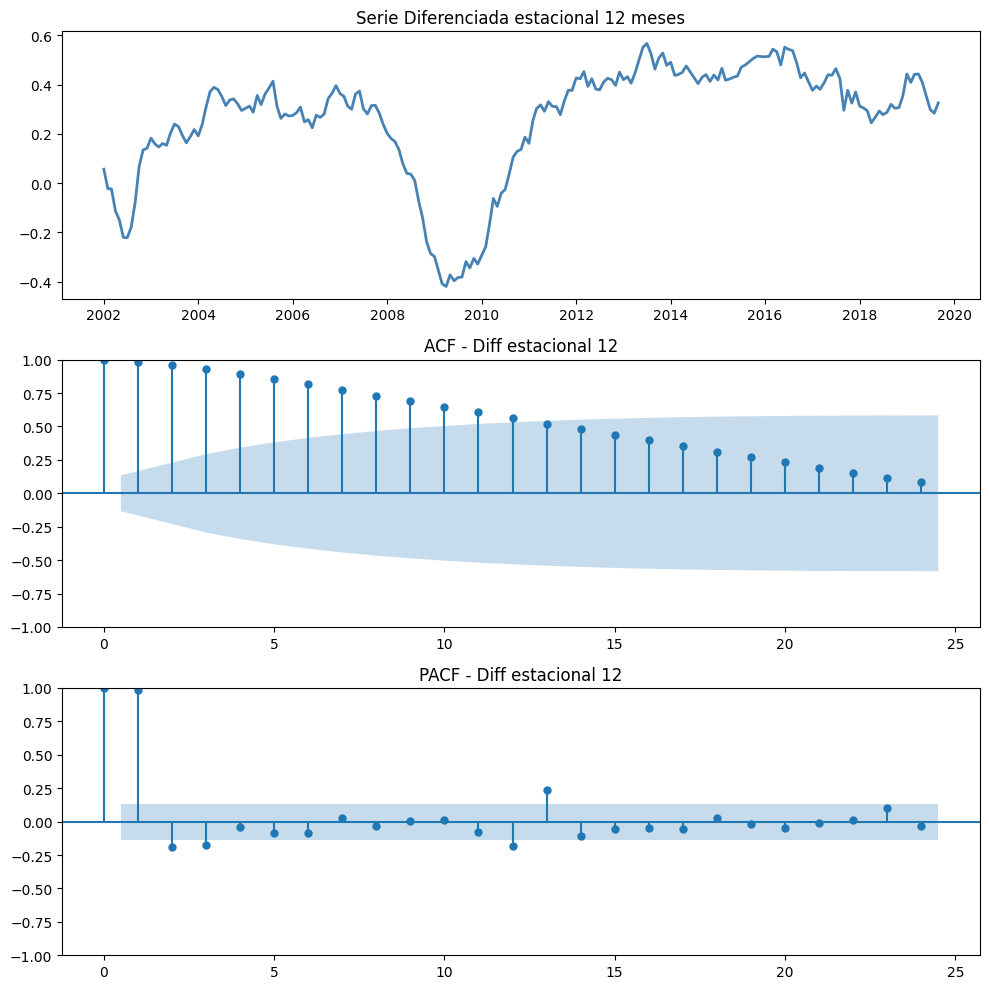

In [3]:
# Diferencia estacional
diff_s12_serie_us_employment = serie_us_employment.diff(12).dropna()

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(diff_s12_serie_us_employment.index, diff_s12_serie_us_employment, color='steelblue', linewidth=2)
axes[0].set_title('Serie Diferenciada estacional 12 meses')
plot_acf(diff_s12_serie_us_employment, ax=axes[1], title=f'ACF - Diff estacional 12')
plot_pacf(diff_s12_serie_us_employment, ax=axes[2], title=f'PACF - Diff estacional 12')
plt.tight_layout()
plt.show()

Estos también son claramente no estacionarios, por lo que tomamos una primera diferencia adicional, ver figura siguiente.

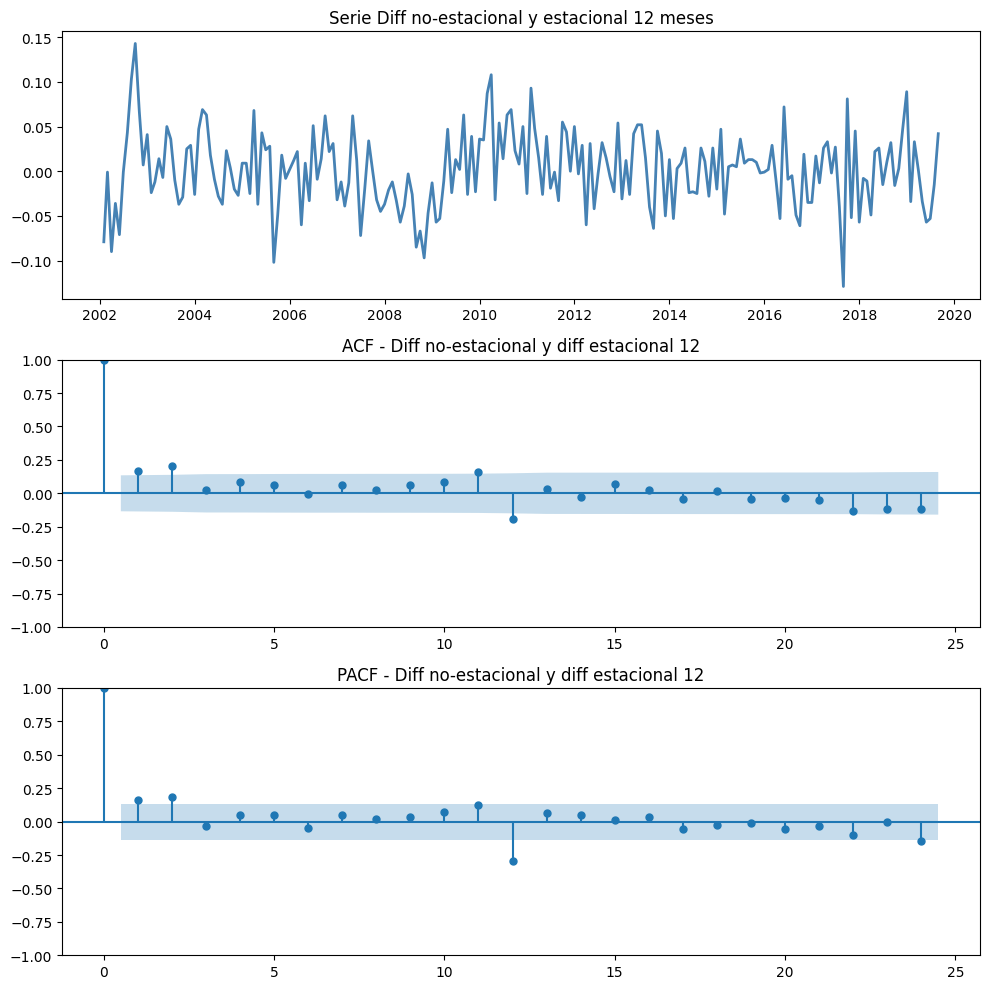

In [4]:
ddiff_s12_serie_us_employment = diff_s12_serie_us_employment.diff().dropna()

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(ddiff_s12_serie_us_employment.index, ddiff_s12_serie_us_employment, color='steelblue', linewidth=2)
axes[0].set_title('Serie Diff no-estacional y estacional 12 meses')
plot_acf(ddiff_s12_serie_us_employment, ax=axes[1], title=f'ACF - Diff no-estacional y diff estacional 12')
plot_pacf(ddiff_s12_serie_us_employment, ax=axes[2], title=f'PACF - Diff no-estacional y diff estacional 12')
plt.tight_layout()
plt.show()

In [5]:
def test_estacionariedad(datos):
    # Augmented Dickey-Fuller
    adf_result = adfuller(datos)
    # KPSS
    kpss_result = kpss(datos, regression='c')

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0],  4), round(kpss_result[0],  4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        "Estacionario" : ["Sí" if adf_result[1] < 0.05 else "No", "No" if kpss_result[1] < 0.05 else "Sí"]
    })

    print("=" * 80)
    print("PRUEBA DE ESTACIONARIEDAD")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)


test_estacionariedad(ddiff_s12_serie_us_employment)

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -3.8213   0.0027           Sí
1                           Prueba KPSS       0.0804   0.1000           Sí


## Definición del modelo
- Nuestro objetivo ahora es encontrar un modelo ARIMA apropiado basándonos en la ACF y la PACF mostradas en la figura anterior. 
- El pico significativo en el rezago 2 de la ACF sugiere un componente MA(2) no estacional. 
- El pico significativo en el rezago 12 de la ACF sugiere un componente MA(1) estacional. 
- En consecuencia, comenzamos con un modelo $ARIMA(0,1,2)(0,1,1)_12$, que indica una primera diferencia, una diferencia estacional y componentes MA(2) no estacional y MA(1) estacional. 
- Si hubiéramos partido de la PACF, podríamos haber seleccionado un modelo $ARIMA(2,1,0)(0,1,1)_12$
- Usando la PACF para seleccionar la parte no estacional del modelo y la ACF para seleccionar la parte estacional. También incluiremos un modelo seleccionado automáticamente.

## Construcción del modelo SARIMA (0,1,2)(0,1,1)12​
- Parte Regular (0,1,2):
    - p = 0 : No componente autoregresivo
    - d = 1: Estás tomando una diferencia para eliminar la tendencia
    - q = 2: El valor de hoy depende de los errores de los dos meses anteriores
- Parte Estacional (0,1,1,12):
    - P = 0 : No componente autoregresivo
    - D = 1 : Estás restando el valor del mismo mes del año anterior ($Y_t​−Y_{t−12}$​) para eliminar el patrón anual.
    - Q = 1 : El error de este mes está correlacionado con el error del mismo mes del año pasado.
    - s = 12 : Define el ciclo estacional ocurre cada 12 observaciones.

In [6]:
# Estimar modelos SARIMA
arima012011 = ARIMA(serie_us_employment, order=(0, 1, 2), seasonal_order=(0, 1, 1, 12)).fit()
arima210011  = ARIMA(serie_us_employment, order=(2, 1, 0), seasonal_order=(0, 1, 1, 12)).fit()
# Búsqueda exhaustiva (revisa todas las combinaciones)
m_autoarima = auto_arima(serie_us_employment, seasonal=True, m=12, stepwise=False, approximation=False)
auto_sarima = ARIMA(serie_us_employment, order=m_autoarima.order, seasonal_order=m_autoarima.seasonal_order).fit()

# guardar modelos
list_modelos = {"ARIMA(0,1,2)(0,1,1)12" : arima012011, "ARIMA(2,1,0)(0,1,1)12" : arima210011, "AutoSARIMA": auto_sarima}

In [7]:
def comparar_modelos_arima(modelos: dict) -> pd.DataFrame:
    df_modelos = (
        pd.DataFrame({
            "Modelo"  : list(modelos),
            "AIC"     : [m.aic       for m in modelos.values()],
            "AICc"    : [m.aicc      for m in modelos.values()],
            "BIC"     : [m.bic       for m in modelos.values()],
            "Log-Lik" : [m.llf       for m in modelos.values()],
            "MSE"     : [m.mse       for m in modelos.values()],
            "RMSE"    : [m.mse**0.5  for m in modelos.values()],
            "MAE"     : [m.mae       for m in modelos.values()],
            "Params"  : [m.df_model  for m in modelos.values()],
            "Obs"     : [m.nobs      for m in modelos.values()],
        })
        .sort_values("AICc")
        .assign(Ranking=lambda df: range(1, len(df) + 1))
        .set_index("Ranking")
    )

    mejor      = df_modelos.iloc[0]["Modelo"]
    mejor_aicc = df_modelos.iloc[0]["AICc"]

    print("=" * 100)
    print("COMPARACIÓN DE MODELOS ARIMA")
    print("=" * 100)
    print(df_modelos.to_string())
    print("-" * 100)
    print(f"Mejor modelo (menor AICc): {mejor}  →  AICc: {mejor_aicc}")
    print("=" * 100)

comparar_modelos_arima(list_modelos)

COMPARACIÓN DE MODELOS ARIMA
                        Modelo         AIC        AICc         BIC     Log-Lik       MSE      RMSE       MAE  Params  Obs
Ranking                                                                                                                  
1                   AutoSARIMA -779.898801 -779.607539 -763.115870  394.949401  0.733049  0.856183  0.116353       5  225
2        ARIMA(2,1,0)(0,1,1)12 -776.155226 -775.961989 -762.728880  392.077613  0.733090  0.856207  0.116613       4  225
3        ARIMA(0,1,2)(0,1,1)12 -774.869539 -774.676302 -761.443194  391.434770  0.733098  0.856211  0.116838       4  225
----------------------------------------------------------------------------------------------------
Mejor modelo (menor AICc): AutoSARIMA  →  AICc: -779.6075392581433


In [8]:
# Reporte modelo
mejor_modelo = list_modelos['AutoSARIMA']
print(mejor_modelo.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  225
Model:             ARIMA(2, 1, 0)x(1, 1, [1], 12)   Log Likelihood                 394.949
Date:                            Mon, 09 Mar 2026   AIC                           -779.899
Time:                                    10:53:34   BIC                           -763.116
Sample:                                01-01-2001   HQIC                          -773.116
                                     - 09-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1786      0.059      3.015      0.003       0.062       0.295
ar.L2          0.1854      0.074   

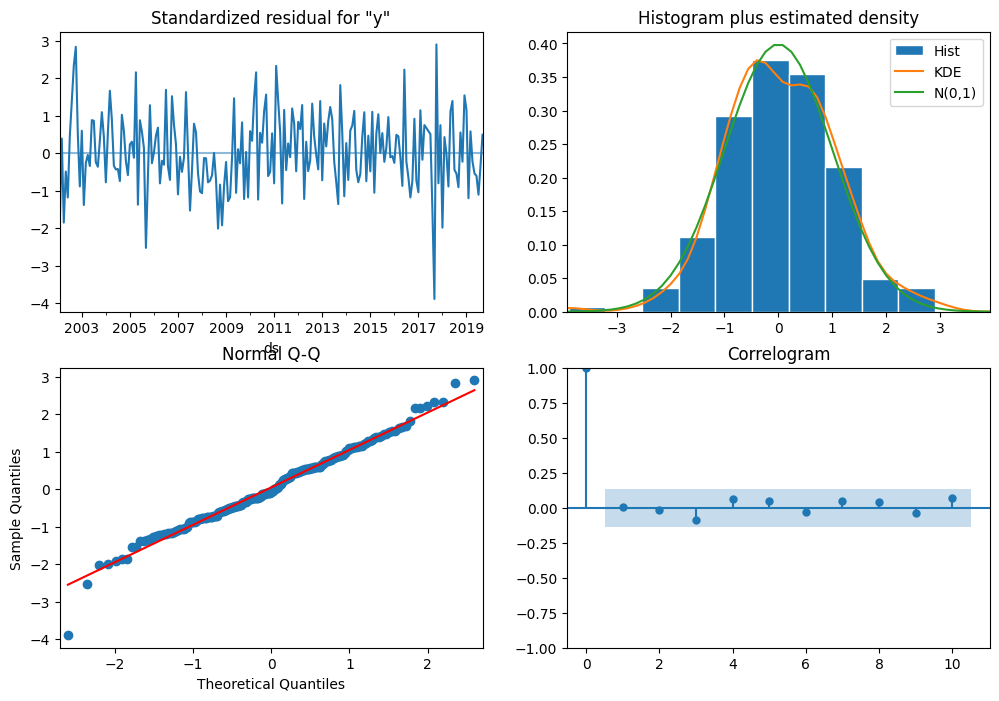

In [9]:
# Verificar ruido blanco
# Diagnostico del modelo
mejor_modelo.plot_diagnostics(figsize=(12,8))
plt.show()

## Pronóstico mejor modelo
Así, ahora contamos con un modelo ARIMA estacional que supera las verificaciones requeridas y está listo para realizar pronósticos. 
- Los pronósticos del modelo para los próximos tres años se muestran en la figura siguiente. 
- Los pronósticos han captado muy bien el patrón estacional, y la tendencia creciente extiende el patrón reciente. La tendencia en los pronósticos está inducida por la doble diferenciación.

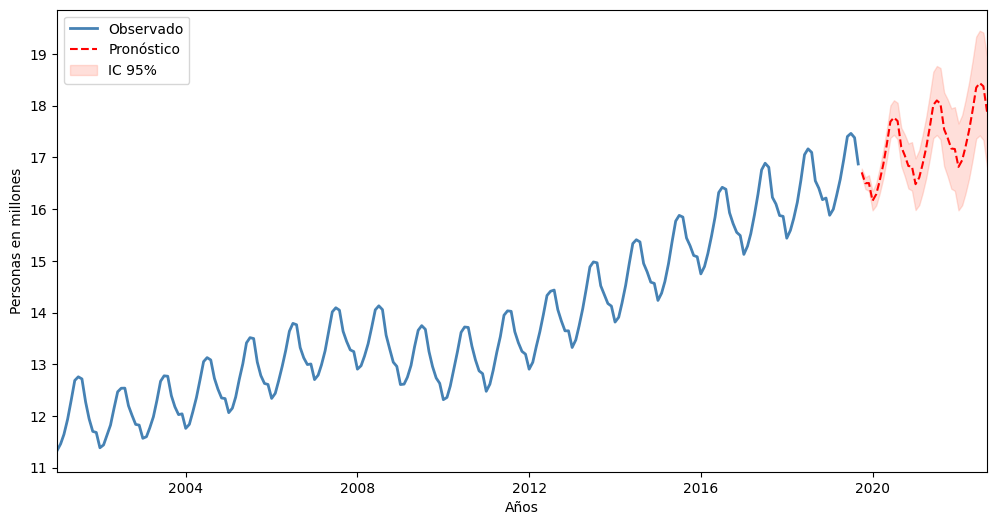

In [10]:
# Pronostico de los proximos 3 años = 12 meses * 3 años  = 36
t_pronostico = 36
ultimo_dato  = serie_us_employment.index[-1]
anio_pronostico = pd.date_range(start=ultimo_dato + pd.offsets.MonthBegin(1), periods=t_pronostico, freq='MS')

# Obtener valores promedios e intervalos del pronostico
pronostico = mejor_modelo.get_forecast(steps=t_pronostico)
pred_mean = pronostico.predicted_mean
pred_ci = pronostico.conf_int()

# Alinear índice con la serie original
pred_mean.index = anio_pronostico
pred_ci.index   = anio_pronostico

# Graficar resultados pronostico
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(serie_us_employment.index, serie_us_employment, label="Observado", color='steelblue', linewidth=2)
ax.plot(pred_mean.index, pred_mean, label="Pronóstico", color='red', linestyle='--')
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color='tomato', alpha=.2, label="IC 95%"
)
ax.set_xlim(pd.Timestamp('2001-01-01'), anio_pronostico[-1])
ax.set_xlabel('Años')
ax.set_ylabel('Personas en millones')
ax.legend()
plt.show()